# 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# 2. Summarization

## 2.1 Baseline on validation set (Year 2)

In [14]:
baseline_val = pd.read_csv("../report/seed_summary_baseline_val_report.csv")
baseline_val

,mean,std,min,max
0,192.429871,0.0,192.429871,192.429871
1,37029.253906,0.0,37029.253906,37029.253906
2,141.231628,0.0,141.231628,141.231628
3,0.068087,0.0,0.068087,0.068087
4,0.775864,0.0,0.775864,0.775864


## 2.2 Time features on validation Set (Year 2)

In [15]:
time_val = pd.read_csv("../report/seed_summary_dow_val_report.csv")
time_val

,mean,std,min,max
0,160.267535,0.736088,159.367752,161.408798
1,25686.116797,236.197125,25398.078125,26052.798828
2,115.223355,0.375530,114.604263,115.528206
3,0.054152,0.000194,0.053839,0.054331
4,0.844523,0.001430,0.842304,0.846267


## 2.3 Lag and Delta GHI, Temp features on Validation Set (Year 2)

In [16]:
lag_del_val = pd.read_csv("../report/seed_summary_delta24_temp_ghi_val_report.csv")
lag_del_val

,mean,std,min,max
0,154.102472,1.180601,152.568451,155.346558
1,23748.685937,363.748871,23277.130859,24132.550781
2,113.469928,0.844691,112.387375,114.367210
3,0.053484,0.000354,0.053109,0.053940
4,0.856250,0.002202,0.853927,0.859105


## 2.4 Raw Dataset Structure

In [19]:
df_train = pd.read_excel("../Dataset/training.xlsx")
df_test = pd.read_excel("../Dataset/testing.xlsx")

In [22]:
final_pred = pd.read_csv("../report/delta24_temp_ghi_test_prediction.csv")

In [26]:
df_test_final = df_test.copy()
df_test_final['Load'] = final_pred['0']

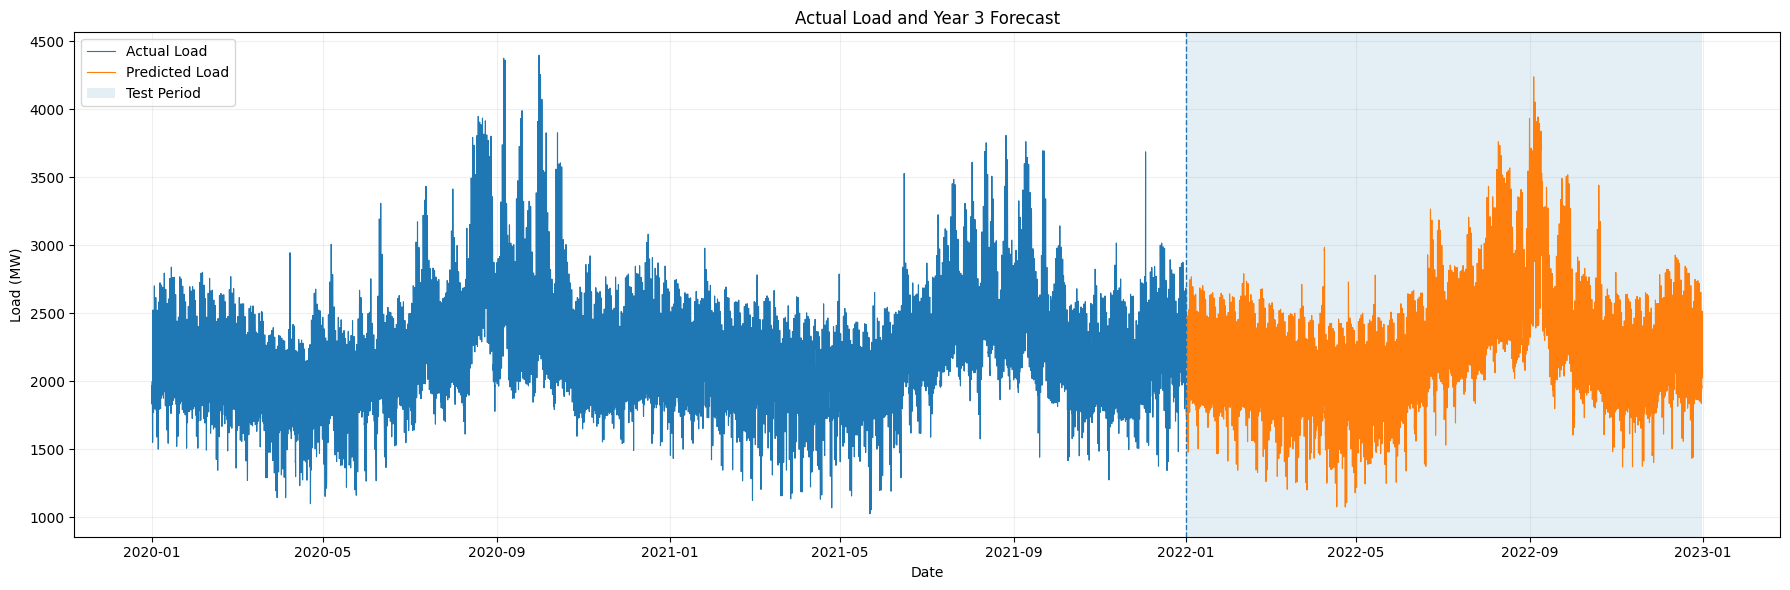

In [30]:
anchor_years = {1: 2020, 2: 2021, 3: 2022}

train_date = pd.to_datetime({
    "year": df_train["Year"].map(anchor_years),
    "month": df_train["Month"],
    "day": df_train["Day"],
    "hour": df_train["Hour"] - 1
})

test_date = pd.to_datetime({
    "year": df_test["Year"].map(anchor_years),
    "month": df_test["Month"],
    "day": df_test["Day"],
    "hour": df_test["Hour"] - 1
})

plt.figure(figsize=(18, 6))

plt.plot(train_date, df_train["Load"], label="Actual Load", linewidth=0.8)
plt.plot(test_date, df_test_final["Load"], label="Predicted Load", linewidth=0.8)

plt.axvspan(
    test_date.min(),
    test_date.max(),
    alpha=0.12,
    label="Test Period"
)

plt.axvline(
    test_date.min(),
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.title("Actual Load and Year 3 Forecast")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()